# Chapter 2: Bear Classifer Model

# Basic setup

In [6]:
#! [ -e /content ] && 
%pip install -Uq fastbook
import fastbook
fastbook.setup_book()

Note: you may need to restart the kernel to use updated packages.


In [8]:
from fastbook import *
from fastai.vision.widgets import *

# Images Collection

## DuckDuckGo

DuckDuckGo search was not working well for images

```bash
%pip install -Uq duckduckgo_search

This was the code from chapter 2 of the book

```py
search_images_ddg

```python

ims = search_images_ddg('grizzly bear', max_images=5)
len(ims)


The following are code from [this guide](https://medium.com/@muhammad_Adam/introduction-to-deep-learning-using-fastai-c25b7828e771) in 2025

```python
from fastdownload import download_url
from ddgs import ddg_images
from fastcore.all import *
from fastdownload import FastDownload
from pathlib import Path
import time, os

def search_images_ddg(keyword, max_images=30):
    # Search for images using DuckDuckGo
    results = ddg_images(term)
    return L(results).itemgot('image')[:max_images]

def download_images(search_term, folder, max_images=30):
    folder = Path(folder)
    folder.mkdir(exist_ok=True)
    urls = search_images_ddg(search_term, max_images=max_images)
    
    for i, url in enumerate(urls):
        try:
            dest = folder/f"{search_term}_{i}.jpg"
            download_url(url, dest, show_progress=False)
            time.sleep(1)  # pause to avoid being blocked
        except Exception as e:
            print(f"Could not download {url}: {e}")

# Example: download bird and not-bird images
download_images("bird", "bird_images", max_images=50)
download_images("not bird", "not_bird_images", max_images=50)

This code is from Gemini

```python
from fastcore.all import *
from fastdownload import download_url
from duckduckgo_search import DDGS  # <--- Use this instead of 'from ddgs import...'

def search_images(term, max_images=30):
    print(f"Searching for '{term}'...")
    with DDGS() as ddgs:
        # This is the modern method call
        results = ddgs.images(term, max_results=max_images)
        return L(results).itemgot('image')

# Test it again
ims = search_images('grizzly bear', max_images=1)
print(f"Found {len(ims)} images")

It throws up a lot of Deprecation and Runtime Warning due to python version incompatibility. I attempted to stop that with the warnings package, which did not work very well

In [9]:
import warnings
# Silence the specific categories bothering you
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

## iCrawler

I use icrawler instead for images downloading

In [11]:
%pip install icrawler
from icrawler.builtin import BingImageCrawler

# This will download 50 images of 'banh mi' directly into a folder
google_crawler = BingImageCrawler(storage={'root_dir': 'data/grizzly_bear'})
google_crawler.crawl(keyword='grizzly_bear', max_num=5)

/home/nathan/miniforge3/lib/python3.13/pty.py:95: DeprecationWarning: This process (pid=577) is multi-threaded, use of forkpty() may lead to deadlocks in the child.
  pid, fd = os.forkpty()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [icrawler]
Note: you may need to restart the kernel to use updated packages.

2026-03-02 10:28:05,311 - INFO - icrawler.crawler - start crawling...
2026-03-02 10:28:05,312 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-03-02 10:28:05,314 - INFO - feeder - thread feeder-001 exit
2026-03-02 10:28:05,315 - INFO - icrawler.crawler - starting 1 parser threads...
2026-03-02 10:28:05,316 - INFO - icrawler.crawler - starting 1 downloader threads...


2026-03-02 10:28:05,863 - INFO - parser - parsing result page https://www.bing.com/images/async?q=grizzly_bear&first=0
2026-03-02 10:28:07,329 - INFO - downloader - image #1	https://wallup.net/wp-content/uploads/2016/01/30094-bears-nature-animals-Grizzly_bear-Grizzly_Bears.jpg
2026-03-02 10:28:08,001 - INFO - downloader - image #2	https://cdn.britannica.com/19/186719-050-887A6F2C/Grizzly-bear-Rocky-Mountains-Wyoming.jpg
2026-03-02 10:28:08,493 - INFO - downloader - image #3	https://eskipaper.com/images/grizzly-bear-4.jpg
2026-03-02 10:28:08,660 - INFO - downloader - image #4	https://d3d0lqu00lnqvz.cloudfront.net/media/media/897b2e5d-6d4c-40fa-bbe8-6829455747e2.jpg
2026-03-02 10:28:09,101 - INFO - downloader - image #5	http://2.bp.blogspot.com/-NjMTuklENdE/UHzVv_8dIxI/AAAAAAAAA-U/tNBsQDn8kFI/s1600/Grizzly+Bear+Pic.jpg
2026-03-02 10:28:09,217 - INFO - downloader - downloaded images reach max num, thread downloader-001 is ready to exit
2026-03-02 10:28:09,219 - INFO - downloader - thread 

This was my attempt at superscript the image files, which did not work 

```python

dest = 'data/grizzly_bear'
im = Image.open(dest)
im.to_thumb(128,128)

#download_url(google_crawler[0], dest, show_progress=FALSE)

Since iCrawler download images directly instead of just url, the following code get the first image and show as a small thumbnail

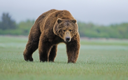

In [15]:
from PIL import Image
from pathlib import Path

# 1. Define your folder
dest = Path('data/grizzly_bear')

# 2. Get a list of all images in that folder
# 'get_image_files' is a handy fastai function for this
from fastai.vision.all import get_image_files
files = get_image_files(dest)

# 3. Open the FIRST file in that list
if len(files) > 0:
    im = Image.open(files[0])
    # Display the thumbnail
    display(im.to_thumb(128,128))
else:
    print("The folder is empty! Crawler might have failed.")

In [ ]:
bear_types = 'grizzly','black','teddy'
path = Path('bears')

In [ ]:
if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest = (path/o)
        dest.mkdir(exist_ok=True)
        results = search_images_bing(key, f'{o} bear')
        download_images(dest, urls=results.attrgot('contentUrl'))

In [ ]:
fns = get_image_files(path)
fns
     

In [ ]:
failed = verify_images(fns)
failed
     

In [ ]:
failed.map(Path.unlink);